### Imports necesarios para el Análisis

In [1]:
import os
from dotenv import load_dotenv
import pandas as pd
from sqlalchemy import create_engine
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Conexión a la BBDD


In [2]:
load_dotenv()
MYSQL_PASSWORD = os.getenv("MYSQL_PASSWORD")
MYSQL_HOST = os.getenv("MYSQL_HOST")
MYSQL_PORT = os.getenv("MYSQL_PORT")
MYSQL_USER = os.getenv("MYSQL_USER")
MYSQL_DATABASE = os.getenv("MYSQL_DATABASE")


# Crear motor de conexión
engine = create_engine(
    f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}@{MYSQL_HOST}:{MYSQL_PORT}/{MYSQL_DATABASE}"
)

### Carga del dataset de la tabla RRHH

In [3]:
with engine.connect() :
    query = "SELECT * FROM RRHH_CLEAN;"
    df = pd.read_sql(query, engine)

### Análisis Desempeño

Pregunta de negocio:
> ¿Cuál es el perfil sociodemográfico de los empleados de la empresa y cómo podemos utilizar esta información para diseñar políticas de talento más adaptadas a sus necesidades y potenciar su compromiso y desarrollo profesional?

La unidad de análisis es el **empleado**, identificado en el dataset mediante la variable `ID`.

Cada fila del dataset original representa una **solicitud de absentismo**.

Los pasos de análisis serán:

- Agregar los registros originales por `ID`, construyendo una tabla resumen por empleado.
- Definir perfiles o segmentos de empleados a partir de variables sociodemográficas.
- Analizar cómo se relacionan estos perfiles con variables como absentismo, rendimiento, antigüedad, carga de trabajo y características personales.
- Identificar patrones que puedan orientar políticas de talento más adaptadas.
- Proponer posibles líneas de actuación en materia de conciliación, desarrollo profesional, bienestar, prevención del absentismo y compromiso.

### Clasificación de variables

In [4]:
# A nivel de dominio de variables:
variables_sociodemograficas = [
    "Age", "Education_Desc", "Son", "Pet", "Social_Drinker", "Social_Smoker", "Body_Mass_Index", 
]

variables_laborales = [
    "Service_Time", "Transportation_Expense", "Distance_Residence_Work", "Work_load_Average_Day"
]

variables_desempeño = [
    "Hit_Target", "Disciplinary_Failure"
]

variables_absencia = [
    "Reason_Absence_Desc",  "Absenteeism_Hours", "Month_Absence", "Day_Week_Desc", "Season_Desc"
]


df_analisis = df[variables_sociodemograficas + variables_laborales + variables_desempeño + variables_absencia].copy()
df_analisis['ID_Employee'] = df['ID_Employee']

### Definir variables como categóricas y booleanas

In [5]:
variables_categoricas = [
    'Reason_Absence_Desc', 'Month_Absence', 'Day_Week_Desc', 'Season_Desc', 'Education_Desc'
]

variables_booleanas = ['Disciplinary_Failure', 'Social_Drinker', 'Social_Smoker']

variables_discretas = ['Son', 'Pet' ]

variables_continuas = [
    'Transportation_Expense', 'Distance_Residence_Work', 'Work_load_Average_Day', 'Age', 
    'Hit_Target', 'Body_Mass_Index', 'Absenteeism_Hours', 'Service_Time'
]

In [6]:
for col in variables_categoricas:
    df_analisis[col] = df_analisis[col].astype("category")

df_analisis["Education_Desc"] = pd.Categorical(
    df_analisis["Education_Desc"],
    categories=[
        "Educación secundaria",
        "Graduado",
        "Postgrado",
        "Máster o doctorado"
    ],
    ordered=True
)

for col in variables_booleanas:
    df_analisis[col] = df_analisis[col].astype("boolean")

df_analisis.info()

<class 'pandas.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Age                      705 non-null    int64   
 1   Education_Desc           705 non-null    category
 2   Son                      705 non-null    int64   
 3   Pet                      705 non-null    int64   
 4   Social_Drinker           705 non-null    boolean 
 5   Social_Smoker            705 non-null    boolean 
 6   Body_Mass_Index          705 non-null    int64   
 7   Service_Time             705 non-null    int64   
 8   Transportation_Expense   705 non-null    float64 
 9   Distance_Residence_Work  705 non-null    int64   
 10  Work_load_Average_Day    705 non-null    float64 
 11  Hit_Target               705 non-null    int64   
 12  Disciplinary_Failure     705 non-null    boolean 
 13  Reason_Absence_Desc      705 non-null    category
 14  Absenteeism_Hours    

### Generar el dataset por empleado `ID`

#### Comprobar variabilidad del empleado

In [7]:
variables_a_revisar = variables_sociodemograficas + variables_laborales + variables_desempeño + variables_absencia

variabilidad_empleado = (
    df_analisis
    .groupby("ID_Employee")[variables_a_revisar]
    .nunique()
    .reset_index()
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

variabilidad_empleado

,ID_Employee,Age,Education_Desc,Son,Pet,Social_Drinker,Social_Smoker,Body_Mass_Index,Service_Time,Transportation_Expense,Distance_Residence_Work,Work_load_Average_Day,Hit_Target,Disciplinary_Failure,Reason_Absence_Desc,Absenteeism_Hours,Month_Absence,Day_Week_Desc,Season_Desc
0,1,1,1,1,1,1,1,1,1,1,1,17,11,2,13,7,10,5,4
1,2,1,1,1,1,1,1,1,1,1,1,4,2,2,4,3,4,3,2
2,3,1,1,1,1,1,1,1,1,1,1,30,13,2,14,9,12,5,4
3,4,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
4,5,1,1,1,1,1,1,1,1,1,1,14,9,2,5,5,9,5,4
5,6,1,1,1,1,1,1,1,1,1,1,7,5,1,5,2,5,3,4
6,7,1,1,1,1,1,1,1,1,1,1,5,3,2,4,5,4,4,4
7,8,1,1,1,1,1,1,1,1,1,1,2,2,2,1,1,2,2,2
8,9,1,1,1,1,1,1,1,1,1,1,5,4,1,5,6,5,3,4
9,10,1,1,1,1,1,1,1,1,1,1,19,9,1,10,6,10,5,4


#### Generación dataset de empleado

In [8]:
def moda_unica(s):
    """
    Devuelve el valor más frecuente de una serie.
    - Si hay empate, pandas devuelve varias modas; tomamos la primera para obtener
      un único valor por empleado.
    """
    moda = s.mode(dropna=True)
    return moda.iloc[0]

df_empleado = (
    df_analisis
    .groupby("ID_Employee")
    .agg(
        eventos_absentismo=("Absenteeism_Hours", "count"),
        absentismo_total_horas=("Absenteeism_Hours", "sum"),
        absentismo_media_horas=("Absenteeism_Hours", "mean"),
        absentismo_mediana_horas=("Absenteeism_Hours", "median"),
        absentismo_max_horas=("Absenteeism_Hours", "max"),
        mes_ausencia_mas_frecuente=("Month_Absence", moda_unica),
        dia_ausencia_mas_frecuente=("Day_Week_Desc", moda_unica),
        estacion_ausencia_mas_frecuente=("Season_Desc", moda_unica),

        rendimiento_medio=("Hit_Target", "mean"),
        rendimiento_mediana=("Hit_Target", "median"),
        carga_media=("Work_load_Average_Day", "mean"),
        carga_mediana=("Work_load_Average_Day", "median"),

        tuvo_fallo_disciplinario=("Disciplinary_Failure", "max"),

        edad=("Age", "max"),
        educacion=("Education_Desc", "max"),
        hijos=("Son", "max"),
        mascotas=("Pet", "max"),
        bebedor_social=("Social_Drinker", moda_unica),
        fumador_social=("Social_Smoker", moda_unica),

        imc=("Body_Mass_Index", "median"),
        antiguedad=("Service_Time", "max"),
        distancia_trabajo=("Distance_Residence_Work", "median"),
        gasto_transporte=("Transportation_Expense", "median"),
        motivo_ausencia_mas_frecuente=("Reason_Absence_Desc", moda_unica)
    )
    .reset_index()
)

df_empleado

,ID_Employee,eventos_absentismo,absentismo_total_horas,absentismo_media_horas,absentismo_mediana_horas,absentismo_max_horas,mes_ausencia_mas_frecuente,dia_ausencia_mas_frecuente,estacion_ausencia_mas_frecuente,rendimiento_medio,rendimiento_mediana,carga_media,carga_mediana,tuvo_fallo_disciplinario,edad,educacion,hijos,mascotas,bebedor_social,fumador_social,imc,antiguedad,distancia_trabajo,gasto_transporte,motivo_ausencia_mas_frecuente
0,1,23,121,5.260870,4.0,16,8,Jueves,Verano,95.173913,95.0,262.894478,249.7970,True,37,Postgrado,1,1,False,False,29.0,14,11.0,235.0,Consulta médica
1,2,6,25,4.166667,4.5,8,8,Lunes,Verano,93.333333,92.0,241.597000,218.1035,True,48,Educación secundaria,1,5,False,True,33.0,12,29.0,235.0,Sin ausencia registrada
2,3,97,444,4.577320,3.0,32,2,Lunes,Otoño,94.762887,96.0,264.747216,253.9570,True,38,Educación secundaria,0,0,True,False,31.0,18,51.0,179.0,Consulta dental
3,4,1,0,0.000000,0.0,0,0,Martes,Verano,95.000000,95.0,271.219000,271.2190,False,40,Educación secundaria,1,8,True,False,34.0,13,14.0,118.0,Sin ausencia registrada
4,5,18,102,5.666667,8.0,16,9,Lunes,Primavera,91.722222,93.0,266.741389,265.0170,True,43,Educación secundaria,1,0,True,False,38.0,13,20.0,235.0,Ausencia injustificada
5,6,8,72,9.000000,8.0,16,2,Jueves,Otoño,94.875000,94.5,274.829000,274.7285,False,33,Educación secundaria,2,2,False,False,25.0,13,29.0,189.0,Seguimiento de paciente
6,7,6,30,5.000000,3.0,16,3,Jueves,Invierno,94.666667,95.0,303.210833,313.6420,True,39,Educación secundaria,2,0,True,True,24.0,14,5.0,279.0,Enfermedades del sistema genito-urinario
7,8,2,0,0.000000,0.0,0,0,Martes,Otoño,88.000000,88.0,282.718000,282.7180,True,39,Educación secundaria,2,2,True,False,35.0,14,35.0,231.0,Sin ausencia registrada
8,9,8,262,32.750000,8.0,120,3,Martes,Otoño,95.875000,96.5,249.042250,255.3390,False,58,Educación secundaria,2,1,False,False,22.0,16,14.0,228.0,Enfermedades del sistema nervioso
9,10,23,178,7.739130,8.0,40,7,Lunes,Verano,94.000000,93.0,258.764348,253.4650,False,28,Educación secundaria,1,4,True,False,27.0,3,52.0,361.0,Seguimiento de paciente


In [9]:
variables_discretas_empleado = ["hijos", "mascotas"]
variables_booleanas_empleado = ["bebedor_social", "fumador_social", "tuvo_fallo_disciplinario"]
variables_continuas_empleado = [
    "eventos_absentismo", "absentismo_total_horas", "absentismo_media_horas", "absentismo_mediana_horas",
    "absentismo_max_horas", "rendimiento_medio", "rendimiento_mediana", "carga_media","carga_mediana",
     "edad", "imc", "antiguedad", "distancia_trabajo", "gasto_transporte"
]
variables_categoricas_empleado = [
    "educacion", "mes_ausencia_mas_frecuente", "dia_ausencia_mas_frecuente", "estacion_ausencia_mas_frecuente", 
    "motivo_ausencia_mas_frecuente"
] 

### Dataset de Empleado

In [10]:
print(f"Eventos originales: {len(df)}")
print(f"Empleados en tabla agregada: {len(df_empleado)}")
print(f"IDs únicos originales: {df['ID_Employee'].nunique()}")

Eventos originales: 705
Empleados en tabla agregada: 36
IDs únicos originales: 36


#### Estadisticas del dataset Empleado

In [11]:
df_empleado[variables_continuas_empleado+variables_discretas_empleado].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
eventos_absentismo,36.0,19.58,21.47,1.0,5.00,9.00,28.25,97.00
absentismo_total_horas,36.0,140.08,145.25,0.0,24.00,78.00,251.00,476.00
absentismo_media_horas,36.0,6.91,5.79,0.0,4.37,5.33,7.80,32.75
absentismo_mediana_horas,36.0,4.61,2.82,0.0,2.75,3.50,8.00,8.00
absentismo_max_horas,36.0,35.67,38.55,0.0,8.00,16.00,58.00,120.00
rendimiento_medio,36.0,94.52,1.99,88.0,93.96,94.83,95.62,98.50
rendimiento_mediana,36.0,94.75,2.24,88.0,93.88,95.00,96.00,99.00
carga_media,36.0,272.74,19.25,241.6,262.57,270.04,281.58,328.02
carga_mediana,36.0,268.12,20.00,218.1,255.32,265.02,276.89,313.64
edad,36.0,38.33,7.92,27.0,32.00,37.50,43.00,58.00


In [12]:
df_empleado[variables_categoricas_empleado+variables_booleanas_empleado].describe().T


,count,unique,top,freq
educacion,36,4,Educación secundaria,28
mes_ausencia_mas_frecuente,36,10,3,6
dia_ausencia_mas_frecuente,36,5,Lunes,12
estacion_ausencia_mas_frecuente,36,4,Verano,10
motivo_ausencia_mas_frecuente,36,12,Consulta dental,10
bebedor_social,36,2,True,19
fumador_social,36,2,False,29
tuvo_fallo_disciplinario,36,2,True,20


### Perfiles sociodemográficos

In [13]:
df_empleado["grupo_edad"] = pd.cut(
    df_empleado["edad"],
    bins=[0, 29, 40, 50, np.inf],
    labels=["menor de 30", "entre 30 y 40", "entre 40 y 50", "mayor de 50"]

)

df_empleado["grupo_educacion"] = df_empleado["educacion"]

df_empleado["grupo_hijos"] = pd.cut(
    df_empleado["hijos"],
    bins=[-1, 0, 1, np.inf],
    labels=["Sin hijos", "1 hijo", "2 o más hijos"]
)

df_empleado["grupo_mascotas"] = pd.cut(
    df_empleado["mascotas"],
    bins=[-1, 0, 1, 2, np.inf],
    labels=["Sin mascotas", "1 mascota", "2 mascotas", "3 o más mascotas"]
)

df_empleado["grupo_bebedor_social"] = df_empleado["bebedor_social"].map({
    False: "No bebedor",
    True: "Bebedor social"
})

df_empleado["grupo_fumador_social"] = df_empleado["fumador_social"].map({
    False: "No fumador",
    True: "Fumador social"
})

df_empleado["grupo_imc"] = pd.cut(
    df_empleado["imc"],
    bins=[0, 24.9, 29.9, np.inf],
    labels=["normal", "sobrepeso", "obesidad"]
)

df_empleado["grupo_distancia"] = pd.cut(
    df_empleado["distancia_trabajo"],
    bins=[0, 15, 35, np.inf],
    labels=["cerca", "media", "lejos"]
)

df_empleado["grupo_gasto_transporte"] = pd.qcut(
    df_empleado["gasto_transporte"],
    q=3,
    labels=["bajo", "medio", "alto"],
    duplicates="drop"
)

df_empleado["grupo_antiguedad"] = pd.cut(
    df_empleado["antiguedad"],
    bins=[0, 5, 15, np.inf],
    labels=["baja", "media", "alta"]
)

df_empleado[[
    "ID_Employee", "grupo_edad", "grupo_educacion", "grupo_hijos",
    "grupo_mascotas", "grupo_bebedor_social", "grupo_fumador_social", 
    "grupo_imc", "grupo_distancia", "grupo_gasto_transporte", "grupo_antiguedad"
]]

,ID_Employee,grupo_edad,grupo_educacion,grupo_hijos,grupo_mascotas,grupo_bebedor_social,grupo_fumador_social,grupo_imc,grupo_distancia,grupo_gasto_transporte,grupo_antiguedad
0,1,entre 30 y 40,Postgrado,1 hijo,1 mascota,No bebedor,No fumador,sobrepeso,cerca,medio,media
1,2,entre 40 y 50,Educación secundaria,1 hijo,3 o más mascotas,No bebedor,Fumador social,obesidad,media,medio,media
2,3,entre 30 y 40,Educación secundaria,Sin hijos,Sin mascotas,Bebedor social,No fumador,obesidad,lejos,bajo,alta
3,4,entre 30 y 40,Educación secundaria,1 hijo,3 o más mascotas,Bebedor social,No fumador,obesidad,cerca,bajo,media
4,5,entre 40 y 50,Educación secundaria,1 hijo,Sin mascotas,Bebedor social,No fumador,obesidad,media,medio,media
5,6,entre 30 y 40,Educación secundaria,2 o más hijos,2 mascotas,No bebedor,No fumador,sobrepeso,media,bajo,media
6,7,entre 30 y 40,Educación secundaria,2 o más hijos,Sin mascotas,Bebedor social,Fumador social,normal,cerca,alto,media
7,8,entre 30 y 40,Educación secundaria,2 o más hijos,2 mascotas,Bebedor social,No fumador,obesidad,media,medio,media
8,9,mayor de 50,Educación secundaria,2 o más hijos,1 mascota,No bebedor,No fumador,normal,cerca,medio,alta
9,10,menor de 30,Educación secundaria,1 hijo,3 o más mascotas,Bebedor social,No fumador,sobrepeso,lejos,alto,baja


#### Empleado Perfil Medio

In [14]:
perfil_medio_numerico = (
    df_empleado[variables_continuas_empleado + variables_discretas_empleado]
    .agg(["mean", "median", "min", "max"])
    .T
    .round(2)
)

perfil_medio_categorico = (
    df_empleado[variables_categoricas_empleado + variables_booleanas_empleado]
    .mode(dropna=True)
    .iloc[0]
    .to_frame(name="valor_mas_frecuente")
)

display(perfil_medio_numerico)
display(perfil_medio_categorico)

perfil_medio = pd.concat(
    [
        perfil_medio_numerico['median'],
        perfil_medio_categorico["valor_mas_frecuente"]
    ],
    axis=0
)

perfil_medio

,mean,median,min,max
eventos_absentismo,19.58,9.00,1.0,97.00
absentismo_total_horas,140.08,78.00,0.0,476.00
absentismo_media_horas,6.91,5.33,0.0,32.75
absentismo_mediana_horas,4.61,3.50,0.0,8.00
absentismo_max_horas,35.67,16.00,0.0,120.00
rendimiento_medio,94.52,94.83,88.0,98.50
rendimiento_mediana,94.75,95.00,88.0,99.00
carga_media,272.74,270.04,241.6,328.02
carga_mediana,268.12,265.02,218.1,313.64
edad,38.33,37.50,27.0,58.00


,valor_mas_frecuente
educacion,Educación secundaria
mes_ausencia_mas_frecuente,3
dia_ausencia_mas_frecuente,Lunes
estacion_ausencia_mas_frecuente,Verano
motivo_ausencia_mas_frecuente,Consulta dental
bebedor_social,True
fumador_social,False
tuvo_fallo_disciplinario,True


eventos_absentismo                                  9.0
absentismo_total_horas                             78.0
absentismo_media_horas                             5.33
absentismo_mediana_horas                            3.5
absentismo_max_horas                               16.0
rendimiento_medio                                 94.83
rendimiento_mediana                                95.0
carga_media                                      270.04
carga_mediana                                    265.02
edad                                               37.5
imc                                                25.0
antiguedad                                         13.0
distancia_trabajo                                  25.5
gasto_transporte                                  235.0
hijos                                               1.0
mascotas                                            0.0
educacion                          Educación secundaria
mes_ausencia_mas_frecuente                      

#### Porcentaje representativo de la plantilla de empleados por segmento

In [15]:
segmentos = [
    "grupo_edad", "grupo_educacion", "grupo_hijos", "grupo_mascotas",
    "grupo_bebedor_social", "grupo_fumador_social", "grupo_imc",
    "grupo_distancia", "grupo_gasto_transporte", "grupo_antiguedad"
]

for col in segmentos:
    tabla = (
        df_empleado[col]
        .value_counts(dropna=False)
        .rename_axis(col)
        .reset_index(name="empleados")
    )
    tabla["porcentaje"] = (tabla["empleados"] / len(df_empleado) * 100).round(2)
    print(f"\nSegmento: {col}")
    display(tabla)


Segmento: grupo_edad


,grupo_edad,empleados,porcentaje
0,entre 30 y 40,19,52.78
1,entre 40 y 50,10,27.78
2,menor de 30,5,13.89
3,mayor de 50,2,5.56



Segmento: grupo_educacion


,grupo_educacion,empleados,porcentaje
0,Educación secundaria,28,77.78
1,Graduado,4,11.11
2,Postgrado,3,8.33
3,Máster o doctorado,1,2.78



Segmento: grupo_hijos


...

,grupo_distancia,empleados,porcentaje
0,media,15,41.67
1,cerca,11,30.56
2,lejos,10,27.78



Segmento: grupo_gasto_transporte


,grupo_gasto_transporte,empleados,porcentaje
0,bajo,12,33.33
1,medio,12,33.33
2,alto,12,33.33



Segmento: grupo_antiguedad


,grupo_antiguedad,empleados,porcentaje
0,media,26,72.22
1,alta,7,19.44
2,baja,3,8.33


### Visualizaciones del perfil sociodemográfico

In [16]:
grupos_sociodemograficos = [
    "grupo_edad",
    "grupo_educacion",
    "grupo_hijos",
    "grupo_mascotas",
    "grupo_bebedor_social",
    "grupo_fumador_social",
    "grupo_imc"
]

grupos_contexto_talento = [
    "grupo_distancia",
    "grupo_gasto_transporte",
    "grupo_antiguedad"
]

grupos_visualizacion = grupos_sociodemograficos + grupos_contexto_talento

palette_base = ["steelblue", "darkorange", "#2a9d8f", "#e76f51", "#264653", "grey"]

visualizacion_disco = ["grupo_bebedor_social","grupo_fumador_social"]


def tabla_representacion_grupo(df_base, grupo):
    tabla = (
        df_base[grupo]
        .value_counts(dropna=False)
        .rename_axis(grupo)
        .reset_index(name="empleados")
    )
    tabla["porcentaje"] = (tabla["empleados"] / len(df_base) * 100).round(1)
    return tabla

#### Representación de los grupos sociodemográficos

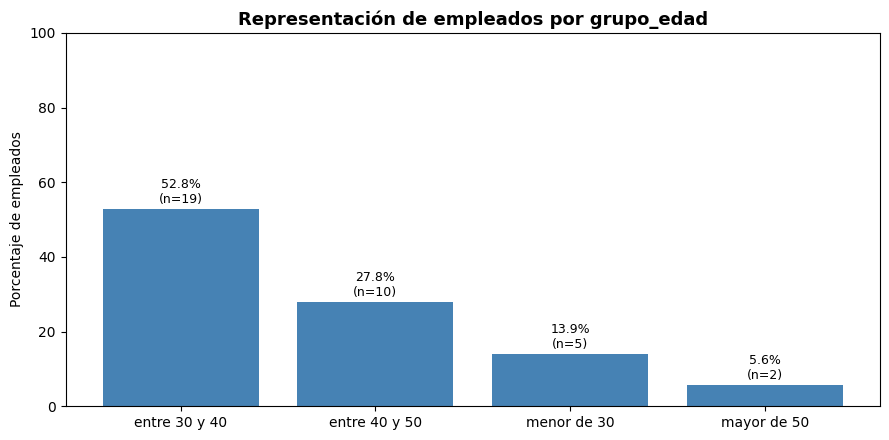

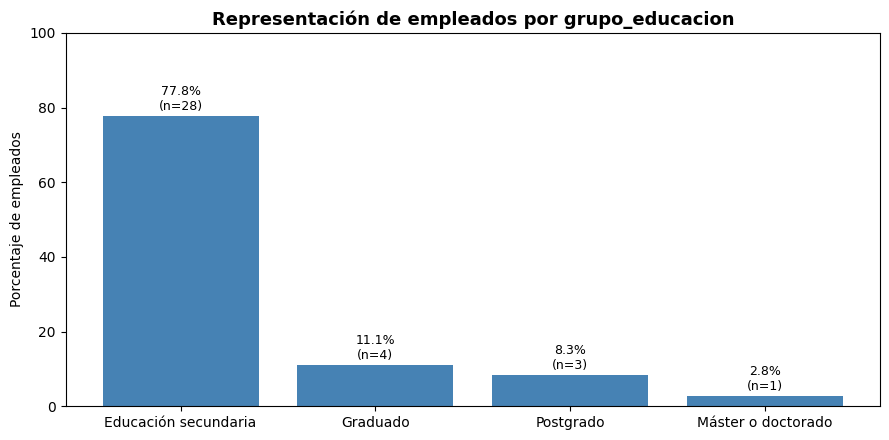

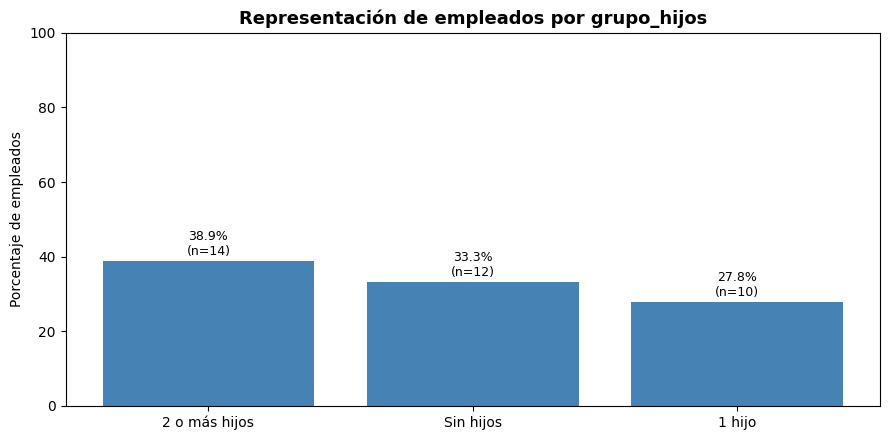

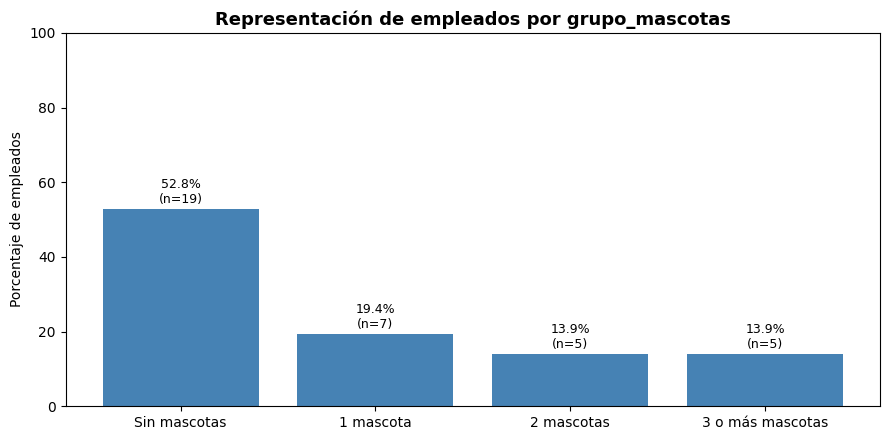

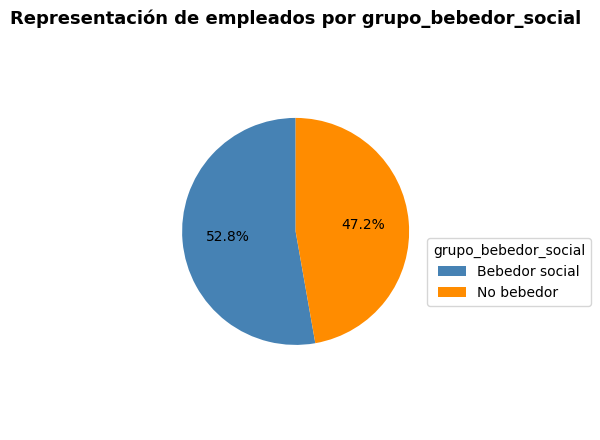

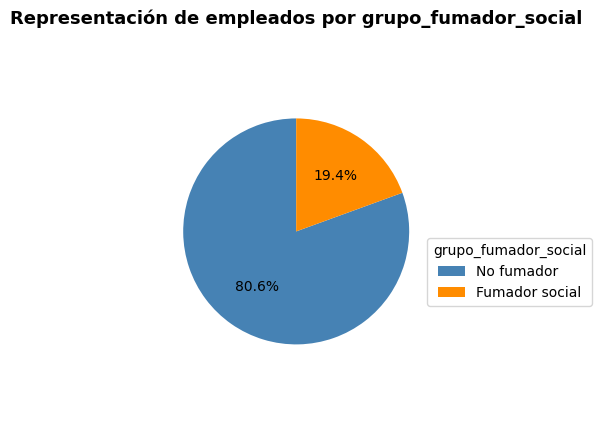

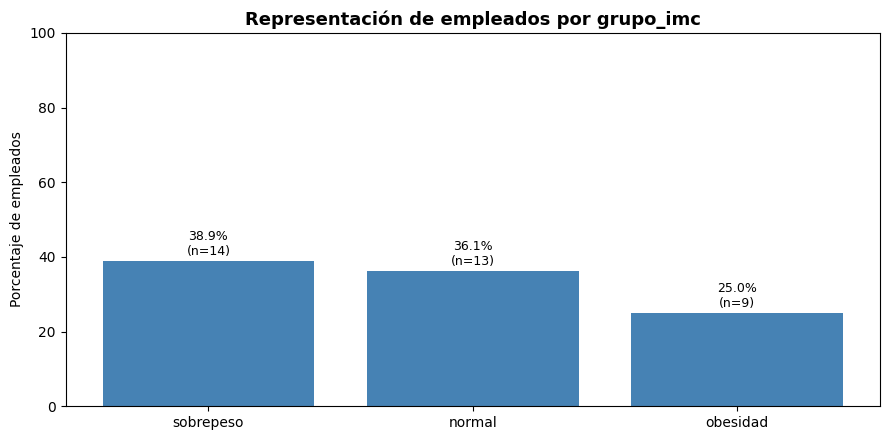

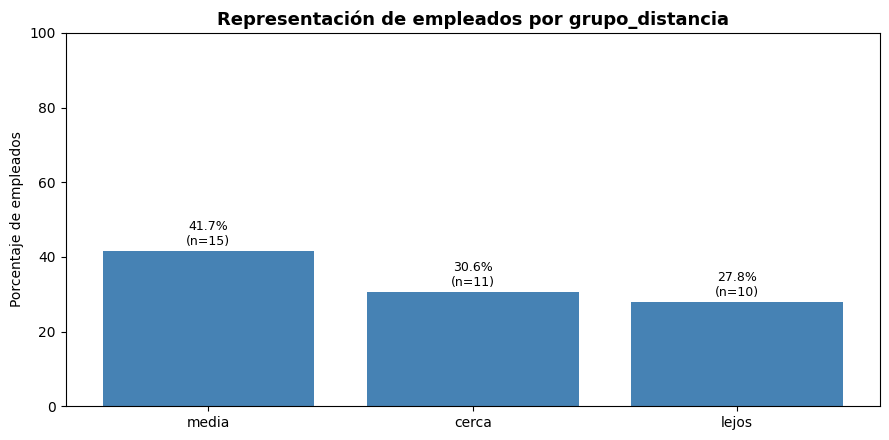

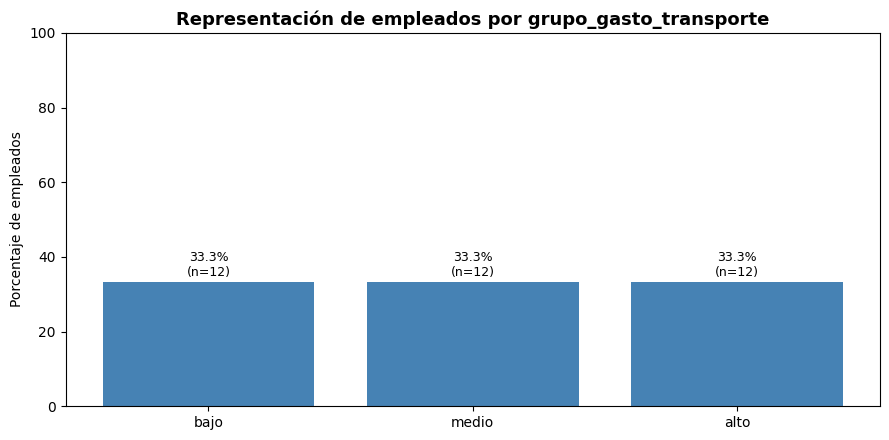

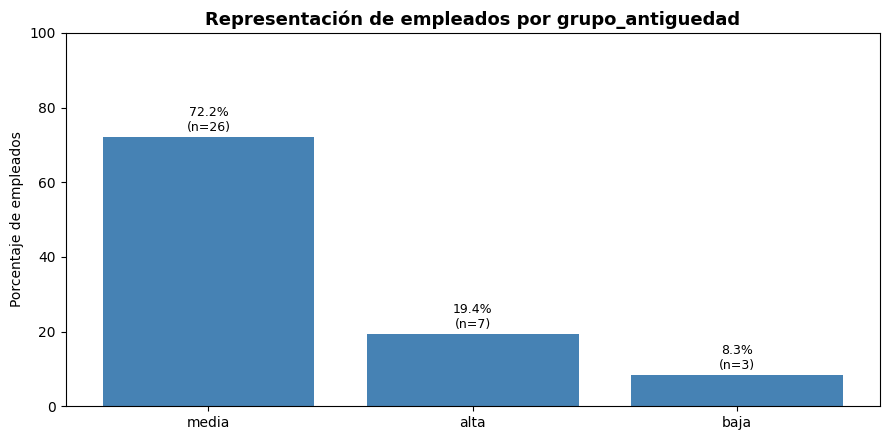

In [17]:
for grupo in grupos_visualizacion:
    tabla = tabla_representacion_grupo(df_empleado, grupo)
    
    if grupo in visualizacion_disco:
        fig, ax = plt.subplots(figsize=(4.5, 4.5))


        wedges, texts, autotexts = ax.pie(
            tabla["empleados"],
            labels=None,
            autopct="%1.1f%%",
            startangle=90,
            colors=palette_base[:len(tabla)],
            textprops={"fontsize": 10},
            radius=1
        )

        ax.legend(
            wedges,
            tabla[grupo].astype(str),
            title=grupo,
            loc="upper left",
            bbox_to_anchor=(1, 0.5)
        )

        ax.set_title(
            f"Representación de empleados por {grupo}",
            fontsize=13,
            fontweight="bold"
        )

        ax.axis("equal")
        plt.subplots_adjust(left=0.05, right=0.72, top=0.88, bottom=0.08)

    else:
        plt.figure(figsize=(9, 4.5))

        bars = plt.bar(tabla[grupo].astype(str), tabla["porcentaje"], color="steelblue")
    
        for bar, pct, n in zip(bars, tabla["porcentaje"], tabla["empleados"]):
            plt.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.8,
                f"{pct:.1f}%\n(n={n})",
                ha="center",
                va="bottom",
                fontsize=9
            )

        plt.xlabel("")
        plt.ylabel("Porcentaje de empleados")
        plt.xticks(rotation=0, ha="center")
        plt.ylim(0, 100)

    plt.title(f"Representación de empleados por {grupo}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

#### Cruces relevantes para perfiles

Estos cruces ayudan a detectar si los empleados se concentran en determinados perfiles compuestos.

Se añaden tres gráficos:

1. Edad × educación: aproxima etapa vital y nivel formativo.
2. Edad × distancia: útil para políticas de movilidad/flexibilidad.
3. Edad × hijos: útil para políticas de conciliación.


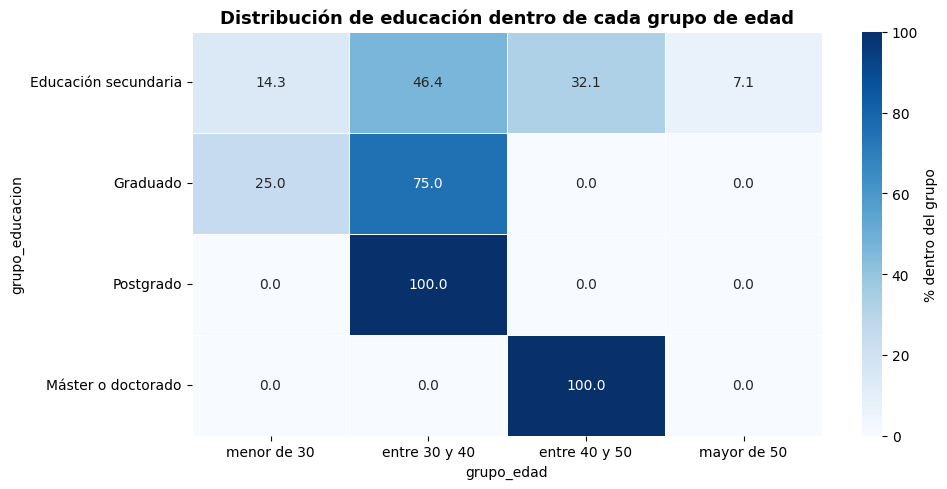

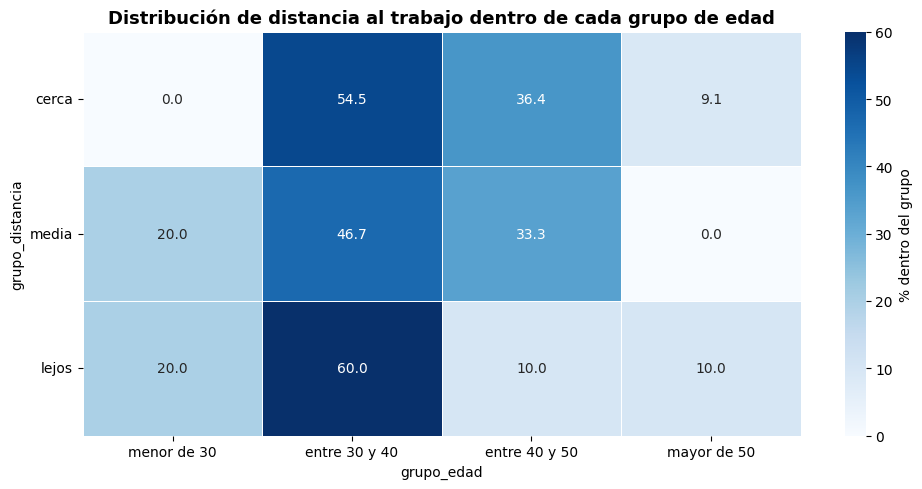

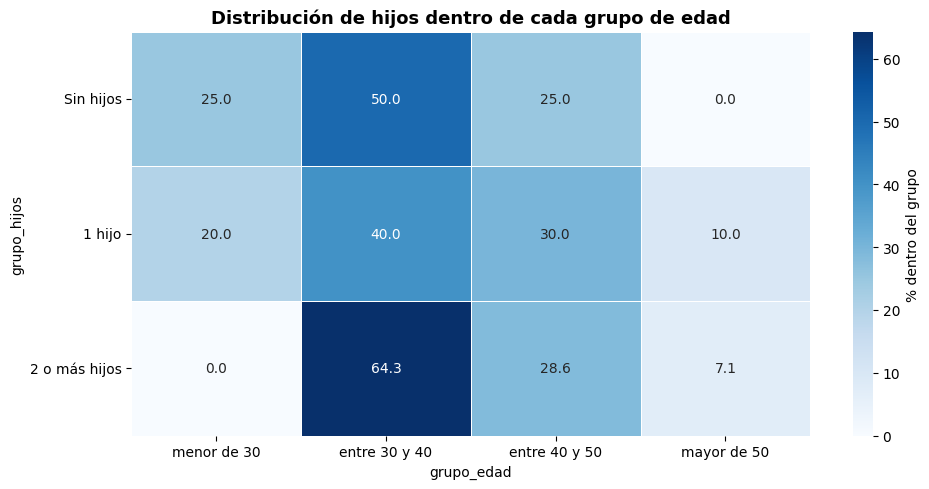

In [18]:
def heatmap_porcentaje_cruce(df_base, fila, columna, titulo):
    tabla = pd.crosstab(
        df_base[fila],
        df_base[columna],
        normalize="index"
    ) * 100
    
    plt.figure(figsize=(10, 5))
    sns.heatmap(
        tabla,
        annot=True,
        fmt=".1f",
        cmap="Blues",
        linewidths=0.5,
        cbar_kws={"label": "% dentro del grupo"}
    )
    plt.title(titulo, fontsize=13, fontweight="bold")
    plt.xlabel(columna)
    plt.ylabel(fila)
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

heatmap_porcentaje_cruce(
    df_empleado,
    "grupo_educacion",
    "grupo_edad",
    "Distribución de educación dentro de cada grupo de edad"
)

heatmap_porcentaje_cruce(
    df_empleado,
    "grupo_distancia",
    "grupo_edad",
    "Distribución de distancia al trabajo dentro de cada grupo de edad"
)

heatmap_porcentaje_cruce(
    df_empleado,
    "grupo_hijos",
    "grupo_edad",
    "Distribución de hijos dentro de cada grupo de edad"
)